ルールベース異常検知
変化が急なので予兆を検知する余裕がない＝異常に入った瞬間を検知
レベルシフト型（中間値に固着）
閾値と判定件数を調整することで見逃しと誤報のバランス制御が可能
介入はコスト次第、高リスク→即停止　低リスク→アラート

DatetimeIndex(['2014-04-11 00:10:00', '2014-04-11 00:15:00',
               '2014-04-11 00:20:00', '2014-04-11 00:25:00',
               '2014-04-11 00:30:00', '2014-04-11 00:35:00',
               '2014-04-11 00:40:00', '2014-04-11 00:45:00',
               '2014-04-11 00:50:00', '2014-04-11 00:55:00',
               ...
               '2014-04-11 22:10:00', '2014-04-11 22:15:00',
               '2014-04-11 22:20:00', '2014-04-11 22:25:00',
               '2014-04-11 22:30:00', '2014-04-11 22:35:00',
               '2014-04-11 22:40:00', '2014-04-11 22:45:00',
               '2014-04-11 22:50:00', '2014-04-11 22:55:00'],
              dtype='datetime64[us]', name='timestamp', length=274, freq=None)


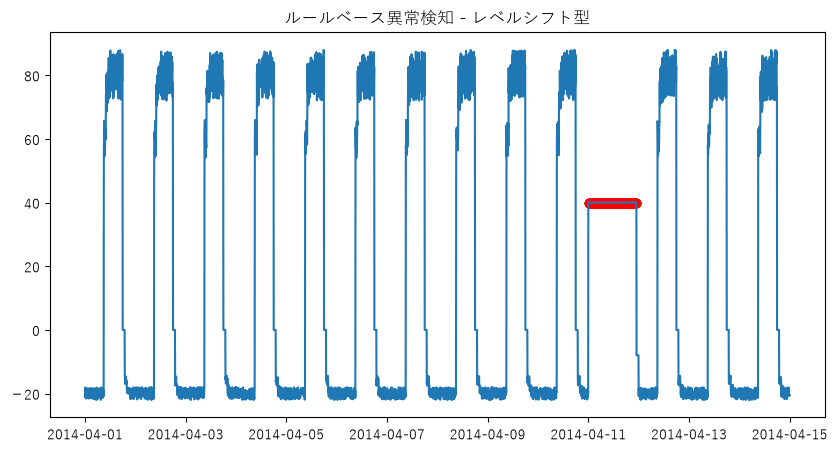

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Yu Gothic'

df=pd.read_csv('art_daily_flatmiddle.csv')

anom = df['value'].between(30, 50)
df['anomaly']=anom.rolling(3).sum()==3

df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')

fig,ax =plt.subplots(figsize=(10,5))
ax.plot(df['value'])
ax.scatter(df.index[df['anomaly']],df['value'][df['anomaly']],color='red')
ax.set_title('ルールベース異常検知 - レベルシフト型')

print(df[df['anomaly']].index)


In [ ]:
from collections import deque

buffer = deque(maxlen=3)

def get_sensor_value():
    return 35  #ダミー

while True:
    buffer.append(get_sensor_value())
    if len(buffer)==3 and all(30<= t <50 for t in buffer):
        print('異常検知')
        break

異常検知
